In this notebook, I investigate different scipy interpolation schemes. We opt to go with the the akima interpolation as it seems to give good curves (that do not oscillate unecessarily) for all the sources. 

### NOTES:

General:
- 1D interpolation routines work by constructing certain piecewise polynomials: the interpolation range is split into intervals by the so-called breakpoints, and there is a certain polynomial on each interval. These polynomial pieces then match at the breakpoints with a predefined smoothness: the second derivatives for cubic splines, the first derivatives for monotone interpolants and so on.
- These splines are defined by the so-called knots and coefficients.


Linear interpolation:
- I.e. broken line interpolation
- numpy.interp or make_interp_spline(..., k=1)
- Continuity = piecewise continuous
- Cannot extrapolate -- see B-splines to do this.
- https://numpy.org/doc/stable/reference/generated/numpy.interp.html#numpy.interp


Cubic spline:
- The interpolating curve is made of cubic pieces with matching first and second derivatives
- CubicSpline. Function can be evaluated at a data point and differentiated
- Continuity = 2nd derivative (i.e. twice continuously differentiable). The first and second derivatives are continuous by construction, and the third derivative jumps at data points.
- The fact that it is twice continuously differentiable may lead to the spline function oscillating and ‘’overshooting’’ in between the data points. In these situations, an alternative is to use the so-called monotone cubic interpolants.
- Boundary conditions for the spline interpolation can be controlled by the bc_type argument to the CubicSpline constructor. By default, it uses the ‘not-a-knot’ boundary condition.
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.CubicSpline.html#scipy.interpolate.CubicSpline


Monotone cubic spline:
- PchipInterpolator and Akima1DInterpolator
- Continuity = 1st derivative. I.e. only once continuously differentiable, and attempt to preserve the local shape implied by the data.
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.Akima1DInterpolator.html#scipy.interpolate.Akima1DInterpolator
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.PchipInterpolator.html#scipy.interpolate.PchipInterpolator


Non-cubic spline / B-spline:
- B-splines form an alternative (if formally equivalent) representation of piecewise polynomials. The B-spline basis is generally more computationally stable than the power basis.The main feature is that these basis elements are localized and equal to zero outside of an interval defined by the knot array.
- make_interp_spline. Function can be evaluated at a data point and differentiated
- Continuity = (k-1)th derivative
- With k=1, make_interp_spline is constructing a linear interpolant with linear extrapolation since make_interp_spline extrapolates by default.
- k=3 is equivalent to CubicSpline. k=3 is the default. So by default, the result of make_interp_spline(x, y) is equivalent to CubicSpline(x, y). The difference is that the former allows several optional capabilities: it can construct splines of various degrees (via the optional argument k) and predefined knots (via the optional argument t).
- Boundary conditions for the spline interpolation can be controlled by the bc_type argument to make_interp_spline function. By default, it uses the ‘not-a-knot’ boundary condition.
- Specifically, a B-spline basis element of degree k (e.g. k=3 for cubics) is defined by k+2 knots and is zero outside of these knots. 
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html#scipy.interpolate.make_interp_spline


Parametric spline curves:
- Curve parametrised by additional parameter u
- Also use make_interp_spline for this


RBF: 
- Can be used for smoothing/interpolating scattered data in N dimensions, but should be used with caution for extrapolation outside of the observed data range.
- RBFInterpolator
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.RBFInterpolator.html#scipy.interpolate.RBFInterpolator


Barycentric interpolation:
- Constructs a Lagrange Polynomial of minimum degree which interpolates the points.
- NOTE: polynomial interpolation itself is a very ill-conditioned process due to the Runge phenomenon.
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.BarycentricInterpolator.html#scipy.interpolate.BarycentricInterpolator



SMOOTHED:


Smoothed splines:
- For the interpolation problem, the task is to construct a curve which passes through a given set of data points. This may be not appropriate if the data is noisy: we then want to construct a smooth curve, g(x), which approximates input data without passing through each point exactly. Smoothing splines balance how close the resulting curve, g(x), is to the data, and the smoothness of g(x). Mathematically, the task is to solve a penalised least-squares problem, where the penalty controls the smoothness of g(x).
- The two approaches below differ in differ in the form of the penalty term, and the basis in which the smoothing curve is constructed.
- Approach 1: 
    - classic smoothing splines, GVC penalty
    - make_smoothing_spline
    - it accepts an optional lam keyword argument to specify the penalty parameter. lam=0 corresponds to the non-smoothed case.
- Approach 2: 
    - automated/semi-automated knot selection
    - make_splrep
    - Instead of the penalty parameter lam, a smoothness parameter s is used. s=0 corresponds to the non-smoothed case.



Lowess:
- LOWESS (Locally Weighted Scatterplot Smoothing)
- https://www.statsmodels.org/dev/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html
- https://tedboy.github.io/statsmodels_doc/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html#statsmodels.nonparametric.smoothers_lowess.lowess
- Example with confidence interval: https://www.statsmodels.org/dev/examples/notebooks/generated/lowess.html

GAMS

---

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator
from scipy.interpolate import interp1d
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import BarycentricInterpolator
from scipy.interpolate import Rbf
from scipy.interpolate import make_interp_spline
import sys
import os
import warnings
import glob
from pathlib import Path

In [3]:
## PLOT FORMATTING

import matplotlib as mpl


plt.rcParams['axes.formatter.useoffset'] = False  # Disable offset mode
plt.rcParams['axes.formatter.use_locale'] = False  # Locale settings can also influence formatting, but this line is optional.
plt.rcParams['axes.formatter.limits'] = (-5, 5)   # Range outside which scientific notation is used; set high to avoid sci-notation.
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['ytick.right'] = True
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['ytick.minor.visible'] = True
mpl.rcParams['ytick.labelsize'] = 'small'
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams['ytick.major.size'] = 6.0
mpl.rcParams['ytick.minor.size'] = 3.0
mpl.rcParams['xtick.top'] = True
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['xtick.labelsize'] = 'small'
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['xtick.major.size'] = 6.0
mpl.rcParams['xtick.minor.size'] = 3.0
mpl.rcParams['axes.linewidth'] = 1.5

In [38]:
sys.path.append(os.path.abspath("../0_UTILITY_FUNCTIONS/"))
from get_data import read_data
from interpolation import merge_close_points

In [90]:
## CODE TO TEST SCIPY INTERPOLATION METHODS

def interpolation_test(xray_df, radio_df, interp_scale="log", types=["linear", "cubic_spline", "akima", "pchip", "bary", "rbf", "interp_spline", "smooth_spline", "lowess"], mjd1 = None, mjd2=None, merge_close_points_bool=False):
    """
    For these tests, I just ignore the upper limits. 
    """

    xray_dates = xray_df["t_xray"].values
    xray_flux = xray_df["Fx"].values
    xray_flux_unc_l = xray_df["Fx_unc_l"].values
    xray_flux_unc_u = xray_df["Fx_unc_u"].values
    xray_uplims = xray_df["Fx_uplim_bool"].values.astype(bool)
    radio_dates = radio_df["t_radio"].values

    if merge_close_points_bool:
        xray_dates, xray_flux, xray_flux_unc_l, xray_flux_unc_u, xray_uplims = merge_close_points(xray_dates, xray_flux, xray_flux_unc_l, xray_flux_unc_u, xray_uplims, threshold=0.1)
    
    # As an approximation, use the upper limits for fitting by setting them to 1.5*sigma, and using a 1*sigma uncertainty
    #xray_flux[xray_uplims] = xray_flux[xray_uplims]/2
    #xray_flux_unc_l[xray_uplims] = xray_flux[xray_uplims]/3
    #xray_flux_unc_u [xray_uplims]= xray_flux[xray_uplims]/3


    # Uplims
    xray_dates_uplims = xray_dates[xray_uplims]
    xray_flux_uplims = xray_flux[xray_uplims]


    # Remove uplims
    xray_dates = xray_dates[~xray_uplims]
    xray_flux= xray_flux[~xray_uplims]
    xray_flux_unc_l = xray_flux_unc_l[~xray_uplims]
    xray_flux_unc_u = xray_flux_unc_u[~xray_uplims]

    x = xray_dates

    y = xray_flux
    yerr_l =  xray_flux_unc_l
    yerr_u =  xray_flux_unc_u
    log_y = np.log10(xray_flux)  
    log_yerr_l =  np.log10(xray_flux) - np.log10(xray_flux - xray_flux_unc_l)
    log_yerr_u =  np.log10(xray_flux + xray_flux_unc_u) - np.log10(xray_flux)
    
    # For zooming in
    if mjd1!=None and mjd2!=None:
        mask = (x >= mjd1) & (x <= mjd2)
        xnew = np.linspace(mjd1, mjd2, num=10000) 
        mask_uplims = (xray_dates_uplims >= mjd1) & (xray_dates_uplims <= mjd2)
    else: 
        mask = np.ones(len(x), dtype=bool)
        xnew = np.linspace(min(x), max(x), num=10000)
        mask_uplims = np.ones(len(xray_dates_uplims), dtype=bool)


    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))


    # Plot the data
    if interp_scale=="log": 
        ax1.errorbar(x[mask], log_y[mask], yerr=[log_yerr_l[mask], log_yerr_u[mask]], marker='.', label='Data', linestyle='none', color="red")
        ax1.scatter(xray_dates_uplims[mask_uplims], np.log10(xray_flux_uplims[mask_uplims]), marker="v", label="3-sigma upper limits", color="red" )
        ax2.errorbar(x[mask], y[mask], yerr=[yerr_l[mask], yerr_u[mask]], marker='.', label='Data', linestyle='none', color="red")
        ax2.scatter(xray_dates_uplims[mask_uplims], xray_flux_uplims[mask_uplims], marker="v", label="3-sigma upper limits", color="red" )
        ax1.set_ylabel("Log X-ray flux")
        ax2.set_ylabel("X-ray flux")
    else: 
        ax1.errorbar(x[mask], y[mask], yerr=[yerr_l[mask], yerr_u[mask]], marker='.', label='Data', linestyle='none', color="red")
        ax1.scatter(xray_dates_uplims[mask_uplims], xray_flux_uplims[mask_uplims], marker="v", label="3-sigma upper limits", color="red" )
        ax2.errorbar(x[mask], log_y[mask], yerr=[log_yerr_l[mask], log_yerr_u[mask]], marker='.', label='Data', linestyle='none', color="red")
        ax2.scatter(xray_dates_uplims[mask_uplims], np.log10(xray_flux_uplims[mask_uplims]), marker="v", label="3-sigma upper limits", color="red" )
        ax1.set_ylabel("X-ray flux")
        ax2.set_ylabel("Log X-ray flux")
    
    
    if mjd1!=None and mjd2!=None: radio_mask = (radio_dates >= mjd1) & (radio_dates <= mjd2)
    else: radio_mask = np.ones(len(radio_dates), dtype=bool)
    for i, date in enumerate(radio_dates[radio_mask]):
        if i==0: 
             ax1.axvline(date, linestyle='-', color='black', alpha=0.1, label="Radio dates")
             ax2.axvline(date, linestyle='-', color='black', alpha=0.1, label="Radio dates")
        else: 
             ax1.axvline(date, linestyle='-', color='black', alpha=0.1)
             ax2.axvline(date, linestyle='-', color='black', alpha=0.1)



    if "linear" in types:
        if interp_scale=="log": 
            bspl = make_interp_spline(x, log_y, k=1)
            ynew = bspl(xnew)
            ax1.plot(xnew, ynew, '-', label='Linear', alpha=1.0) 
            ax2.plot(xnew, 10**ynew, '-', label='Linear', alpha=1.0)
        else:
            bspl = make_interp_spline(x, y, k=1)
            ynew = bspl(xnew)
            ax1.plot(xnew, ynew, '-', label='Linear', alpha=1.0) 
            ax2.plot(xnew, np.log10(ynew), '-', label='Linear', alpha=1.0)


    if "b_spline" in types:
        # k=1 is linear and k=3 is the CubicSpline
        if interp_scale=="log": 
            bspl = make_interp_spline(x, log_y, k=2)
            ynew = bspl(xnew)
            ax1.plot(xnew, ynew, '-', label='B spline k=2', alpha=1.0) 
            ax2.plot(xnew, 10**ynew, '-', label='B spline k=2', alpha=1.0)
        else:
            bspl = make_interp_spline(x, y, k=3)
            ynew = bspl(xnew)
            ax1.plot(xnew, ynew, '-', label='B spline k=2', alpha=1.0) 
            ax2.plot(xnew, np.log10(ynew), '-', label='B spline k=2', alpha=1.0)


    if "cubic_spline" in types:
        if interp_scale=="log": 
            ynew = CubicSpline(x, log_y)(xnew)
            ax1.plot(xnew, ynew, label="Cubic spline", alpha=1.0)
            ax2.plot(xnew, 10**ynew, label="Cubic spline", alpha=1.0)
        else: 
            ynew = CubicSpline(x, y)(xnew)
            ax1.plot(xnew, ynew, label="Cubic spline", alpha=1.0)
            ax2.plot(xnew, np.log10(ynew), label="Cubic spline", alpha=1.0)
    
    if "akima" in types:
         if interp_scale=="log": 
            ynew = Akima1DInterpolator(x, log_y)(xnew)
            ax1.plot(xnew, ynew, '-', label='Akima1D', alpha=1.0)
            ax2.plot(xnew, 10**ynew, '-', label='Akima1D', alpha=1.0)
         else: 
            ynew = Akima1DInterpolator(x, y)(xnew)
            ax1.plot(xnew, ynew, '-', label='Akima1D', alpha=1.0)
            ax2.plot(xnew, np.log10(ynew), '-', label='Akima1D', alpha=1.0)

    if "pchip" in types:
        if interp_scale=="log": 
            ynew = PchipInterpolator(x, log_y, extrapolate=True)(xnew)
            ax1.plot(xnew, ynew, '-', label='pchip', alpha=1.0)
            ax2.plot(xnew, 10**ynew, '-', label='pchip', alpha=1.0)
        else: 
            ynew = PchipInterpolator(x, y, extrapolate=True)(xnew)
            ax1.plot(xnew, ynew, '-', label='pchip', alpha=1.0)
            ax2.plot(xnew, np.log10(ynew), '-', label='pchip', alpha=1.0)
    
    if "bary" in types:
         if interp_scale=="log": 
            ynew = BarycentricInterpolator(x, log_y)(xnew)
            ax1.plot(xnew, ynew, '-', label='Barycentric', alpha=1.0)
            ax2.plot(xnew, 10**ynew, '-', label='Barycentric', alpha=1.0)
         else: 
            ynew = BarycentricInterpolator(x, y)(xnew)
            ax1.plot(xnew, ynew, '-', label='Barycentric', alpha=1.0)
            ax2.plot(xnew, np.log10(ynew), '-', label='Barycentric', alpha=1.0)

    if "rbf" in types:
        if interp_scale=="log": 
            rbf_interp = Rbf(x, log_y, function='thin-plate')  # Options: 'linear', 'cubic', 'gaussian', 'thin_plate'
            ynew = rbf_interp(xnew)
            ax1.plot(xnew, ynew, '-', label='RBF', alpha=1.0)
            ax2.plot(xnew, 10**ynew, '-', label='RBF', alpha=1.0)
        else: 
            rbf_interp = Rbf(x, y, function='thin-plate')  # Options: 'linear', 'cubic', 'gaussian', 'thin_plate'
            ynew = rbf_interp(xnew)
            ax1.plot(xnew, ynew, '-', label='RBF', alpha=1.0)
            ax2.plot(xnew, np.log10(ynew), '-', label='RBF', alpha=1.0)

    
    if "lowess" in types:
        if interp_scale=="log": 
            lowess_fit = lowess(log_y, x, frac=0.001)  # Adjust `frac` for smoothness
            ax1.plot(lowess_fit[:, 0], lowess_fit[:, 1], '-', label='LOWESS', alpha=1.0) 
            ax2.plot(lowess_fit[:, 0], 10**lowess_fit[:, 1], '-', label='LOWESS', alpha=1.0)
        else:
            lowess_fit = lowess(y, x, frac=0.001)  # Adjust `frac` for smoothness
            ax1.plot(lowess_fit[:, 0], lowess_fit[:, 1], '-', label='LOWESS', alpha=1.0) 
            ax2.plot(lowess_fit[:, 0], np.log10(lowess_fit[:, 1]), '-', label='LOWESS', alpha=1.0)


    handles, labels = ax2.get_legend_handles_labels()
    order = [labels.index("Data")] + [i for i, lbl in enumerate(labels) if lbl != "Data"]
    ax2.legend([handles[i] for i in order], [labels[i] for i in order])
    
    ax1.set_xlabel("MJD")
    ax2.set_xlabel("MJD")
    plt.tight_layout()
    plt.show()

In [57]:
def show_merging_effect(source_name, mjd1, mjd2):

    # Show what affect the merging is having
    source_df, obs_df, radio_df, xray_df = read_data(f"../DATA/{source_name}.txt", add_sys_er = True, verbose=True)
    xray_dates = xray_df["t_xray"].values
    xray_flux = xray_df["Fx"].values
    xray_flux_unc_l = xray_df["Fx_unc_l"].values
    xray_flux_unc_u = xray_df["Fx_unc_u"].values
    xray_uplims = xray_df["Fx_uplim_bool"].values.astype(bool)
    radio_dates = radio_df["t_radio"].values

    # We see that there are some data points on top of each other
    mask = (xray_dates >= mjd1) & (xray_dates <= mjd2)
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    ax.errorbar(xray_dates[~xray_uplims & mask], xray_flux[~xray_uplims & mask], yerr= [xray_flux_unc_l[~xray_uplims & mask], xray_flux_unc_u[~xray_uplims & mask]], fmt='.-', color='blue', label='X-ray flux')
    ax.plot(xray_dates[xray_uplims & mask], xray_flux[xray_uplims & mask],  'v', color='green', label='X-ray uplims')
    plt.show()


    xray_dates_test, xray_flux_test, xray_flux_unc_l_test, xray_flux_unc_u_test, xray_uplims_test = merge_close_points(xray_dates, xray_flux, xray_flux_unc_l, xray_flux_unc_u, xray_uplims, threshold=0.1)
    mask = (xray_dates_test >= mjd1) & (xray_dates_test <= mjd2)
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    ax.errorbar(xray_dates_test[~xray_uplims_test & mask], xray_flux_test[~xray_uplims_test & mask], yerr= [xray_flux_unc_l_test[~xray_uplims_test & mask], xray_flux_unc_u_test[~xray_uplims_test & mask]], fmt='.-', color='blue', label='X-ray flux')
    ax.plot(xray_dates_test[xray_uplims_test & mask], xray_flux_test[xray_uplims_test & mask],  'v', color='green', label='X-ray uplims')
    plt.show()

In [40]:
def run_interpolation_test(names=None, types=["cubic_spline", "pchip", "akima", "rbf", "linear"], interp_scale="log", mjd1=None, mjd2=None, merge_close_points_bool=False):
    if names is None:
        folder_path = "../DATA"
        txt_files = glob.glob(f"{folder_path}/*.txt")
        names = []
        for path in txt_files:
            p = Path(path)
            name = p.stem
            names.append(name)


    for name in names:

        source_df, obs_df, radio_df, xray_df = read_data(f"../DATA/{name}.txt", add_sys_er = True, verbose=True)

        if len(xray_df)>1:
            interpolation_test(xray_df, radio_df, interp_scale=interp_scale, types=types, mjd1=mjd1, mjd2=mjd2, merge_close_points_bool=merge_close_points_bool)

---

1A 1744-361
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


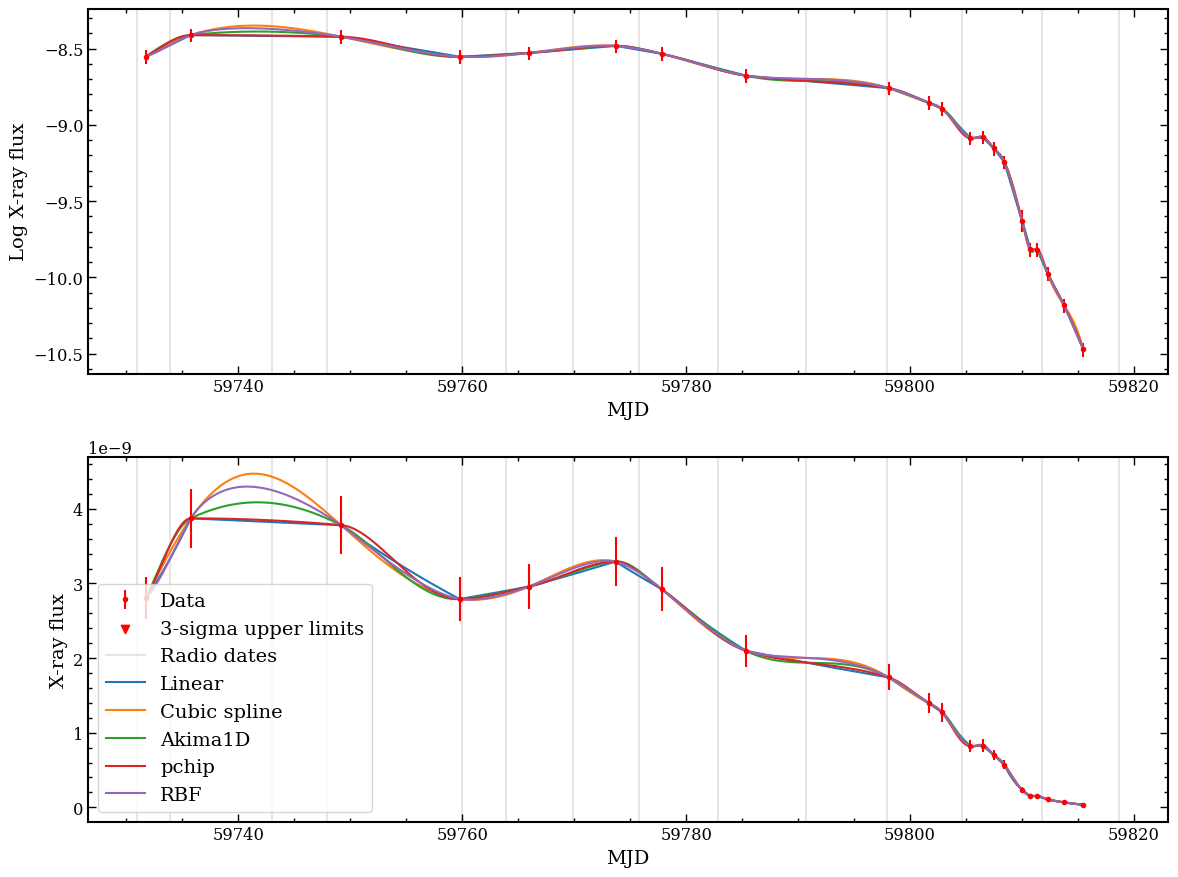

In [22]:
run_interpolation_test(names=["1A 1744-361"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

4U 1543-47
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  90
Converting uncertainties to 68% (assuming Gaussian errors).
Added 10.0% systematic uncertainty to the X-ray data.


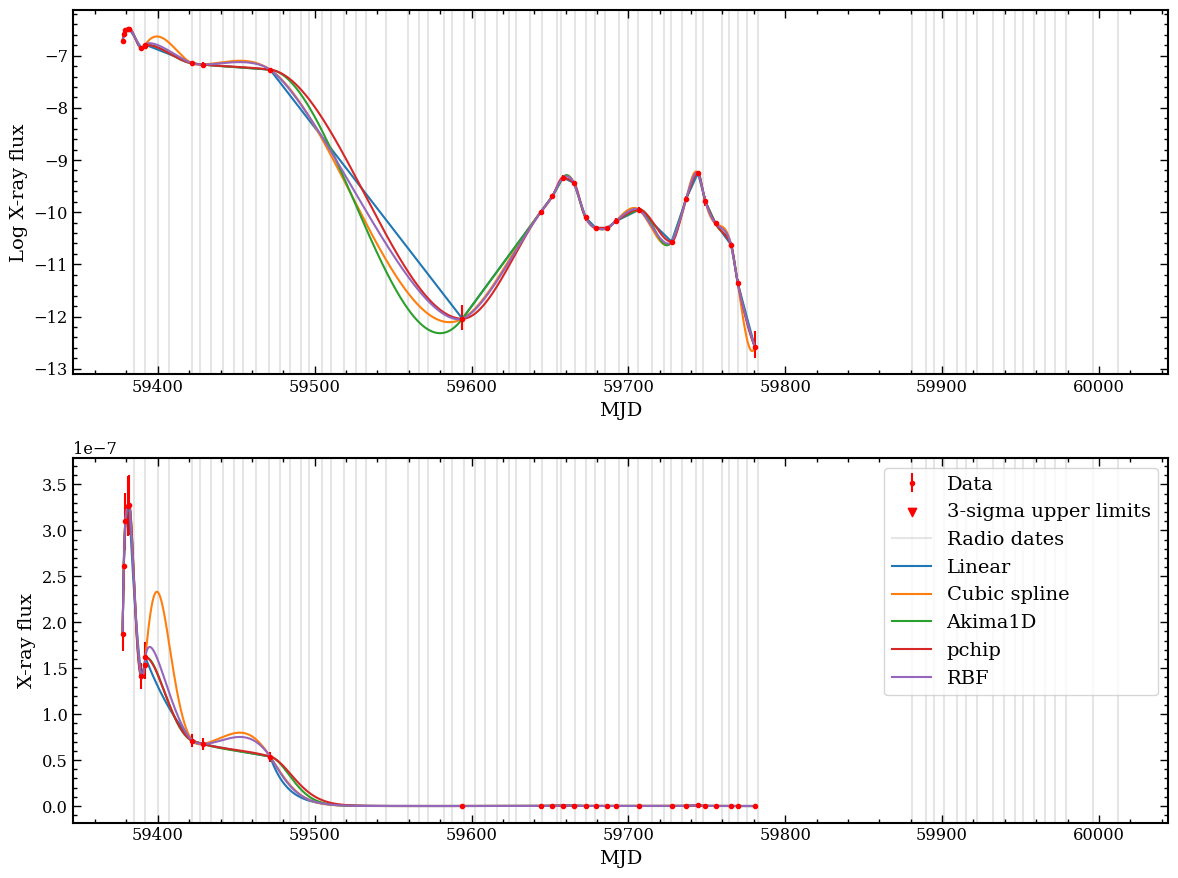

In [24]:
run_interpolation_test(names=["4U 1543-47"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

4U 1630-47
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


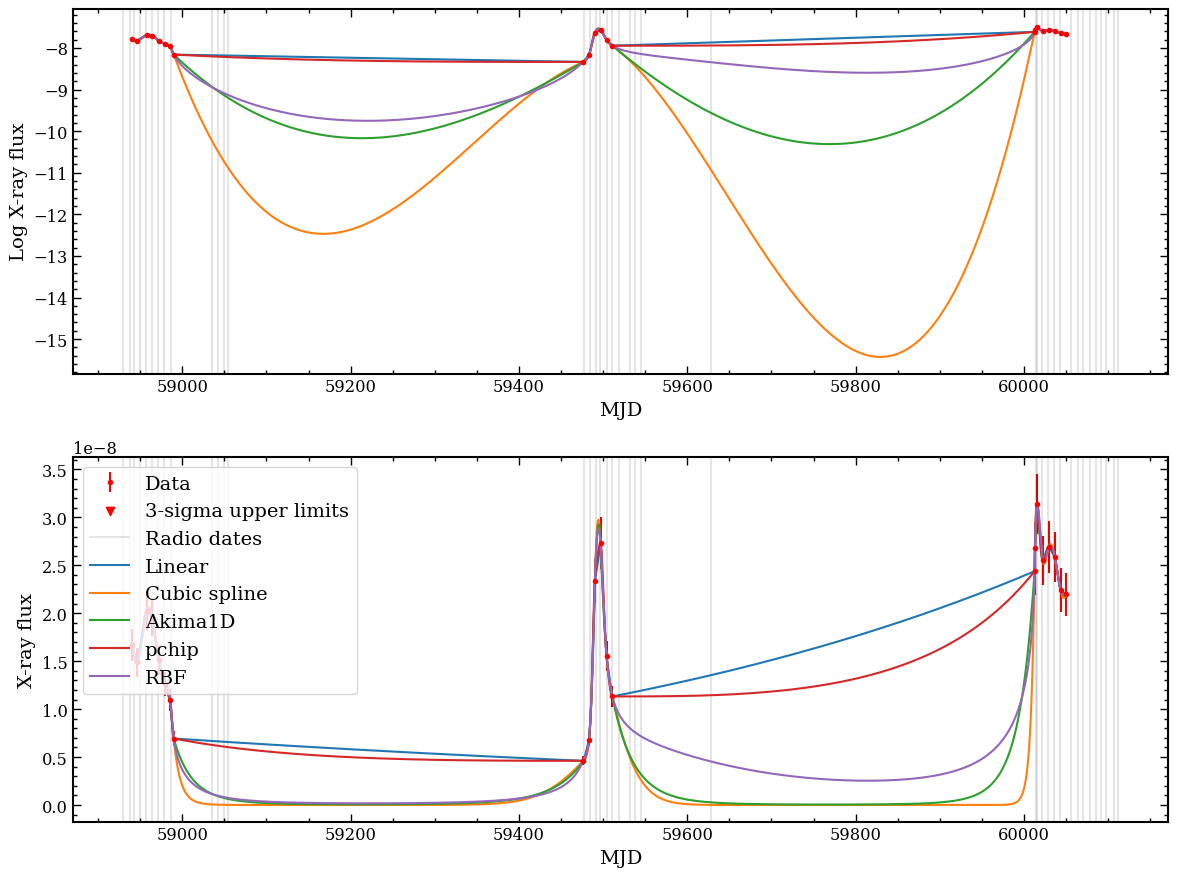

In [25]:
run_interpolation_test(names=["4U 1630-47"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

Cen X-4
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


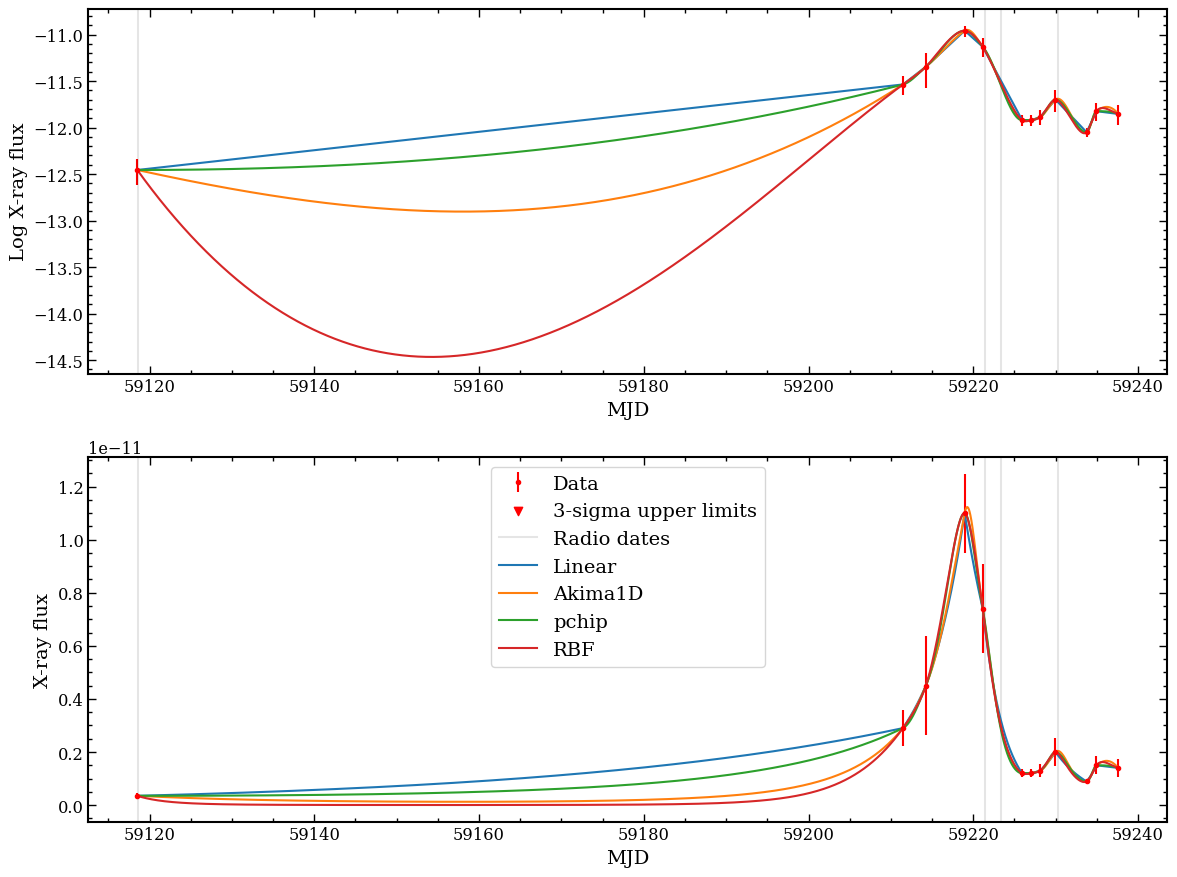

In [27]:
run_interpolation_test(names=["Cen X-4"], types=[ "pchip", "akima", "rbf", "linear"]) #"cubic_spline",

EXO 1846-031
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


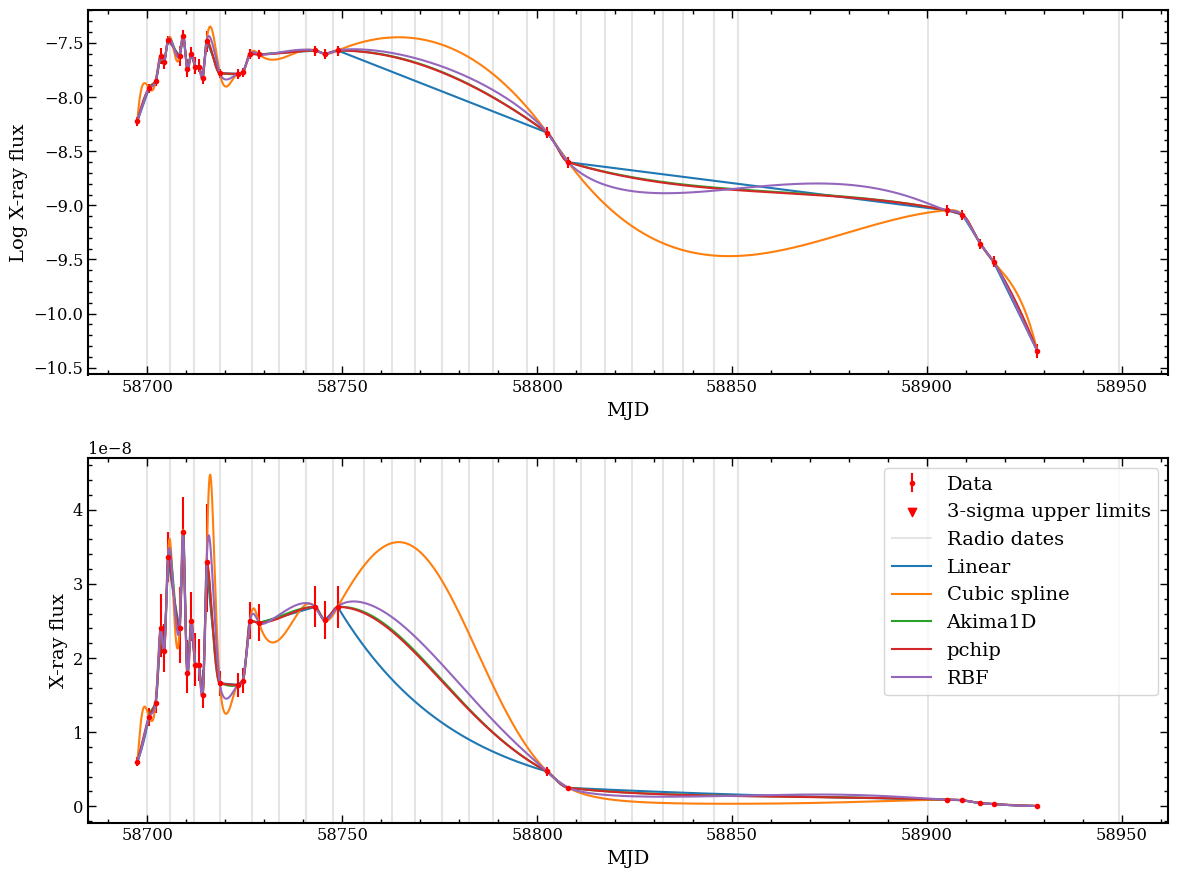

In [28]:
run_interpolation_test(names=["EXO 1846-031"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

GRS 1739-278
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


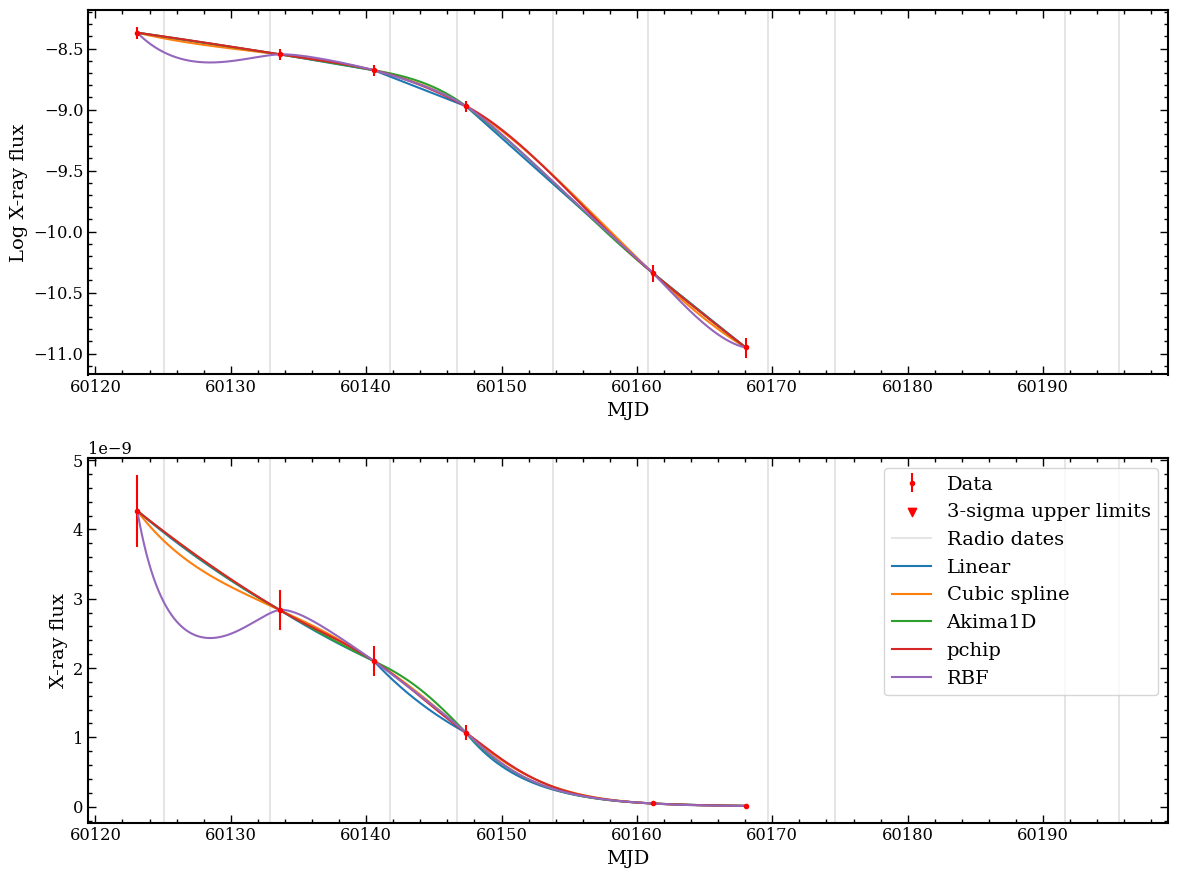

In [29]:
run_interpolation_test(names=["GRS 1739-278"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

GX 339-4
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


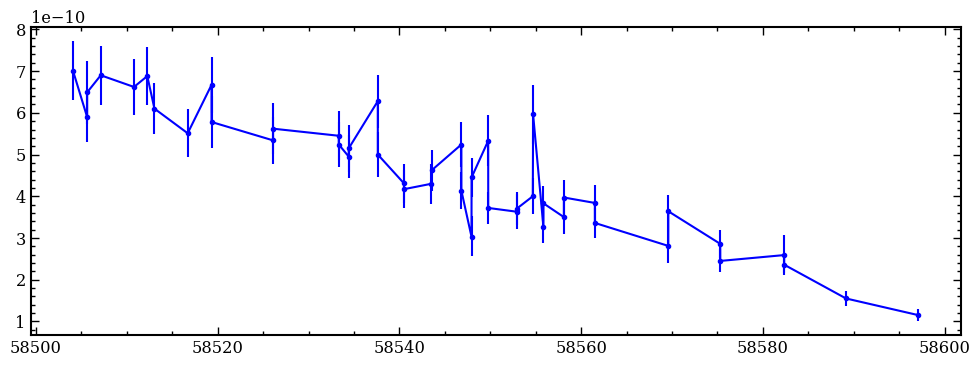

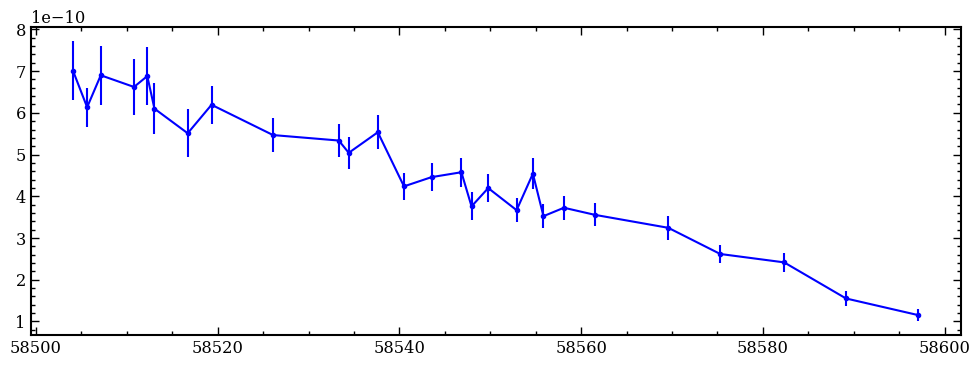

GX 339-4
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


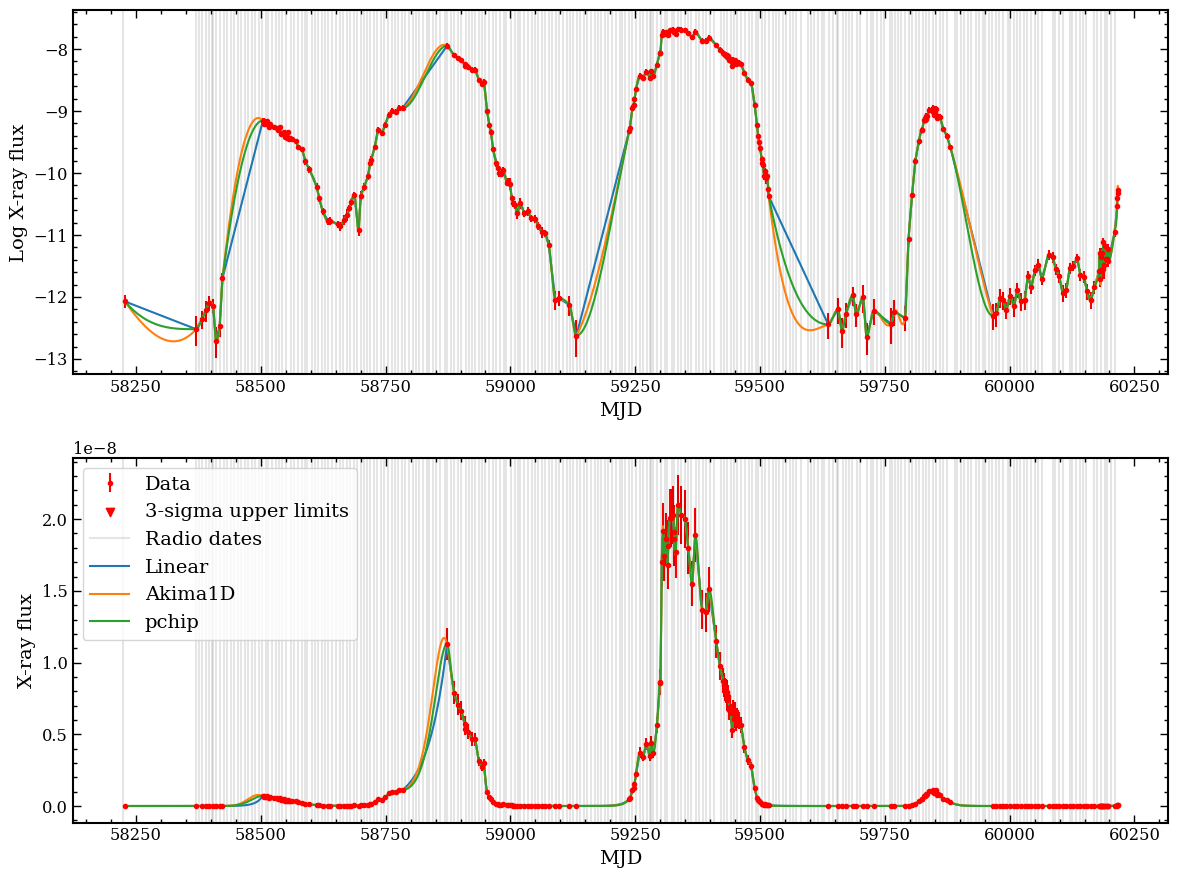

In [59]:
# For this one, I have to merge close points to get the interpolation to work, otherwise it just blows up with the close points. 
show_merging_effect("GX 339-4", mjd1 = 58500, mjd2 = 58600)
run_interpolation_test(names=["GX 339-4"], types=[ "pchip", "akima", "linear"], merge_close_points_bool=True) # "cubic_spline", "rbf",

H1743-322
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


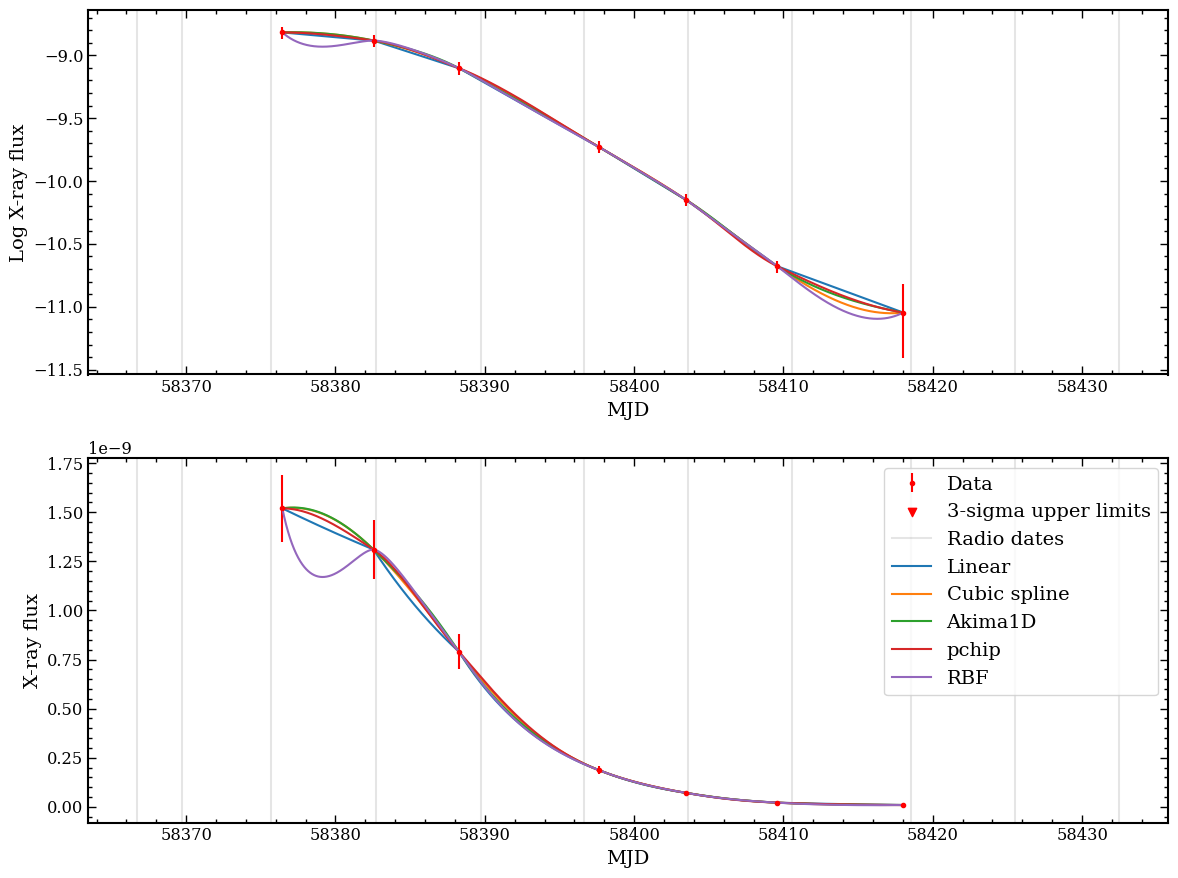

In [47]:
run_interpolation_test(names=["H1743-322"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

IGR J17091-3624
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  90
Converting uncertainties to 68% (assuming Gaussian errors).
Added 10.0% systematic uncertainty to the X-ray data.


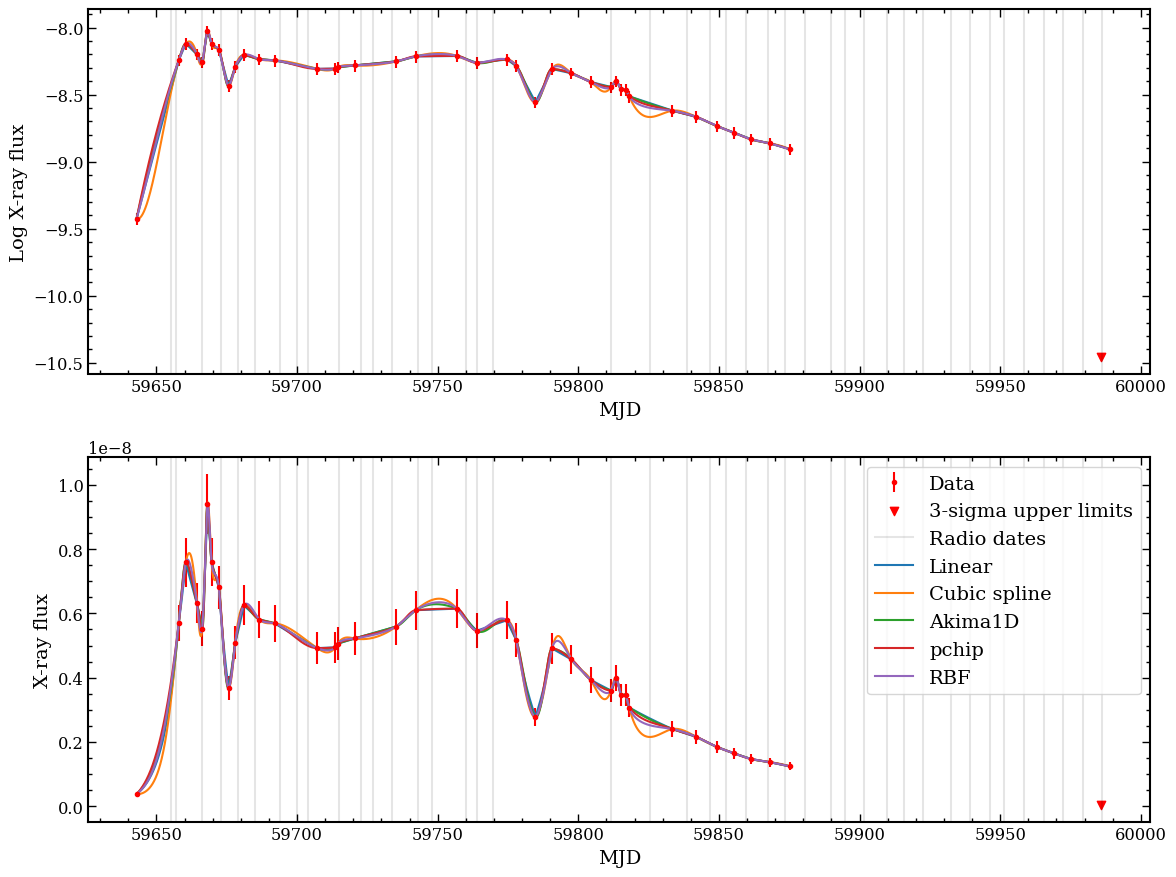

In [48]:
run_interpolation_test(names=["IGR J17091-3624"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

MAXI J1348-630
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  90
Converting uncertainties to 68% (assuming Gaussian errors).
Added 10.0% systematic uncertainty to the X-ray data.


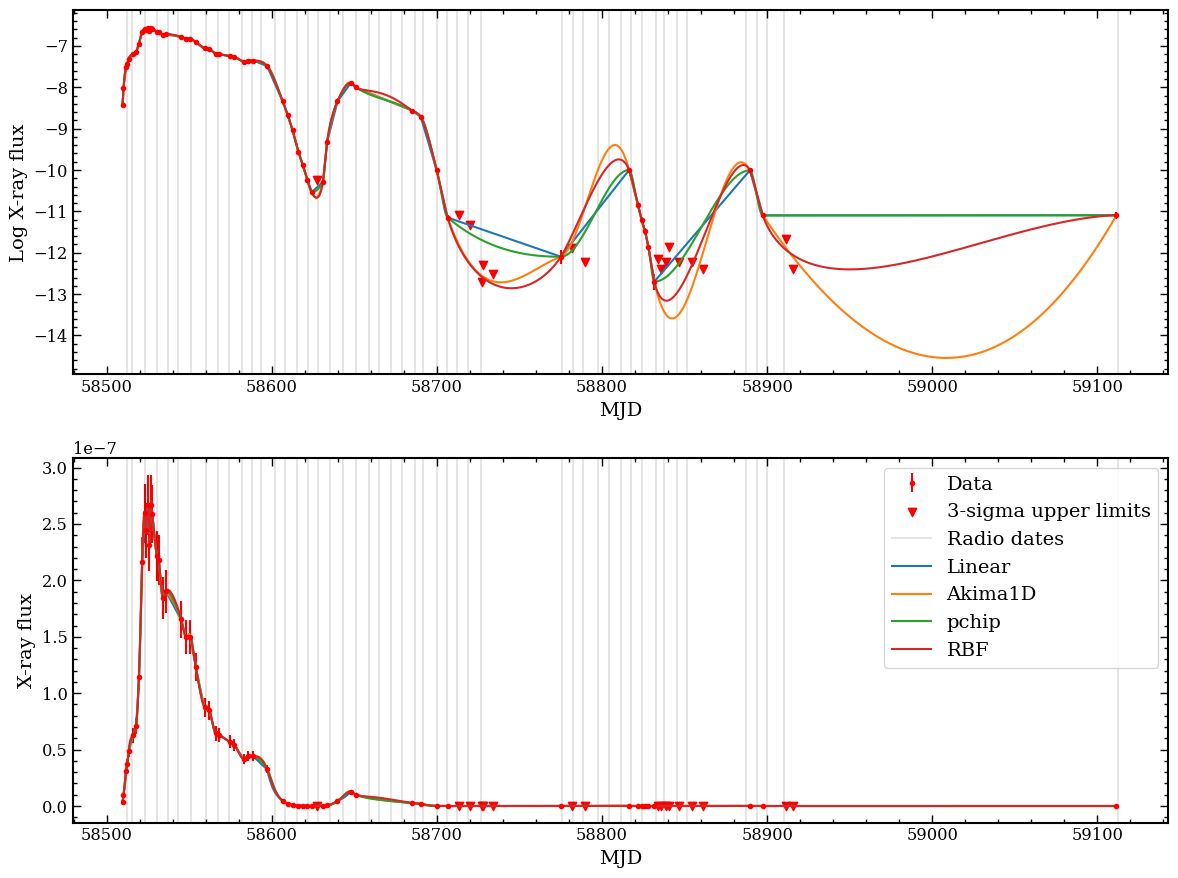

In [50]:
run_interpolation_test(names=["MAXI J1348-630"], types=[ "pchip", "akima", "rbf", "linear"]) # "cubic_spline",

MAXI J1631-479
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


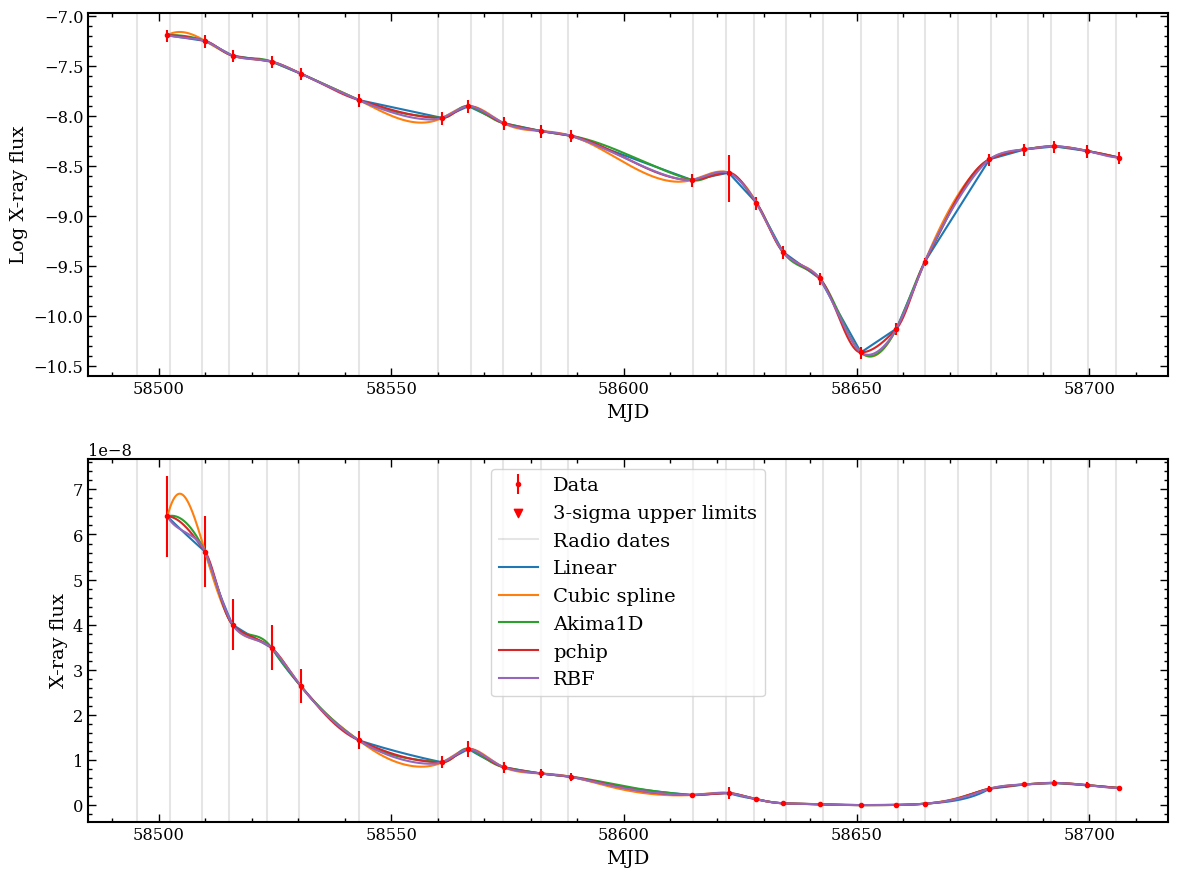

In [51]:
run_interpolation_test(names=["MAXI J1631-479"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

MAXI J1803-298
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  90
Converting uncertainties to 68% (assuming Gaussian errors).
Added 10.0% systematic uncertainty to the X-ray data.


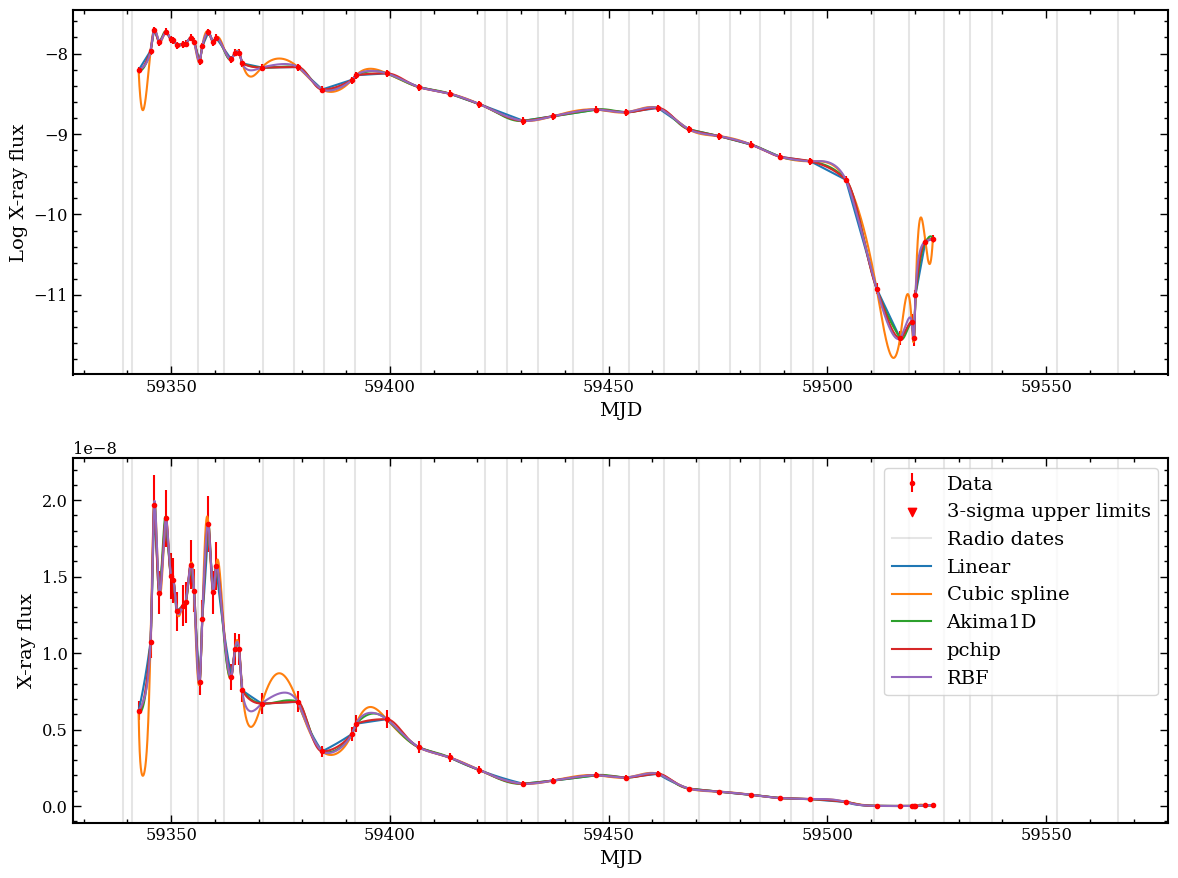

In [52]:
run_interpolation_test(names=["MAXI J1803-298"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

MAXI J1807+132
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


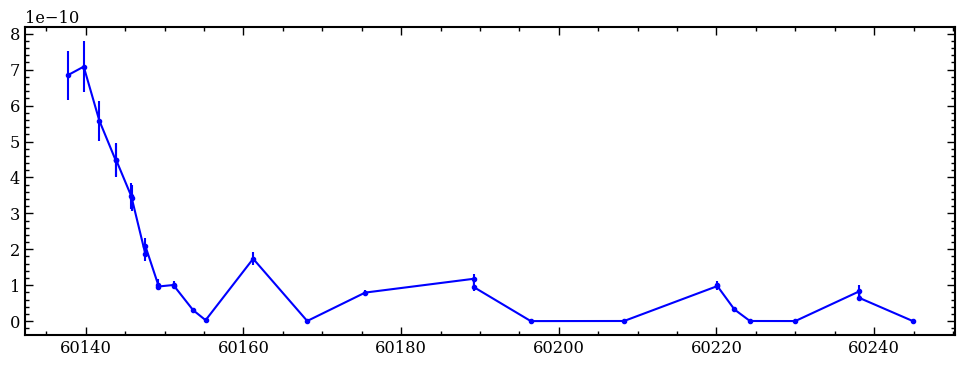

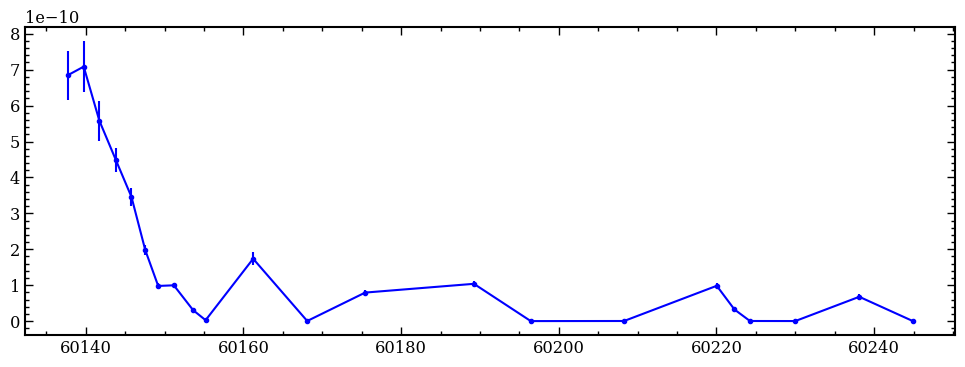

MAXI J1807+132
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


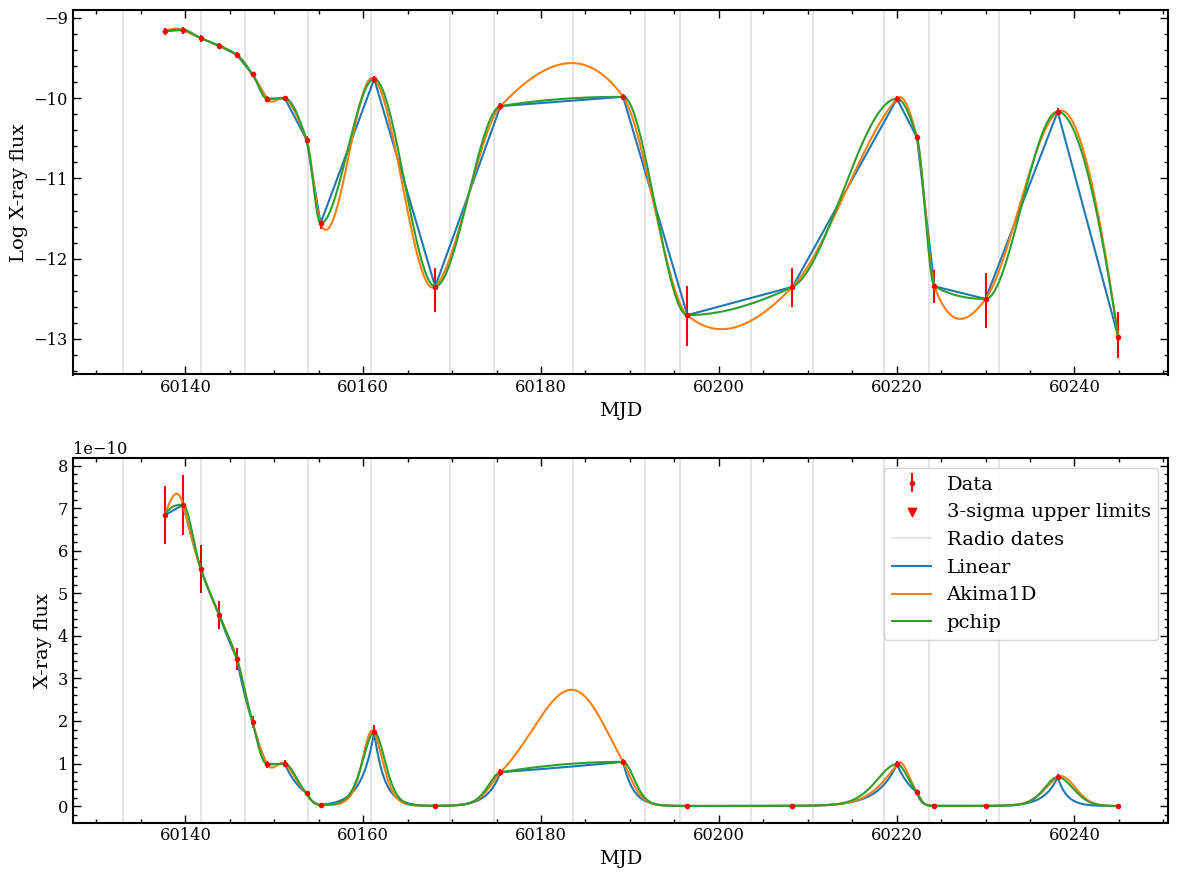

In [60]:
show_merging_effect("MAXI J1807+132", mjd1 = 60135, mjd2 = 60250)
run_interpolation_test(names=["MAXI J1807+132"], types=["pchip", "akima", "linear"], merge_close_points_bool=True) #"cubic_spline", "rbf", 

MAXI J1810-222
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


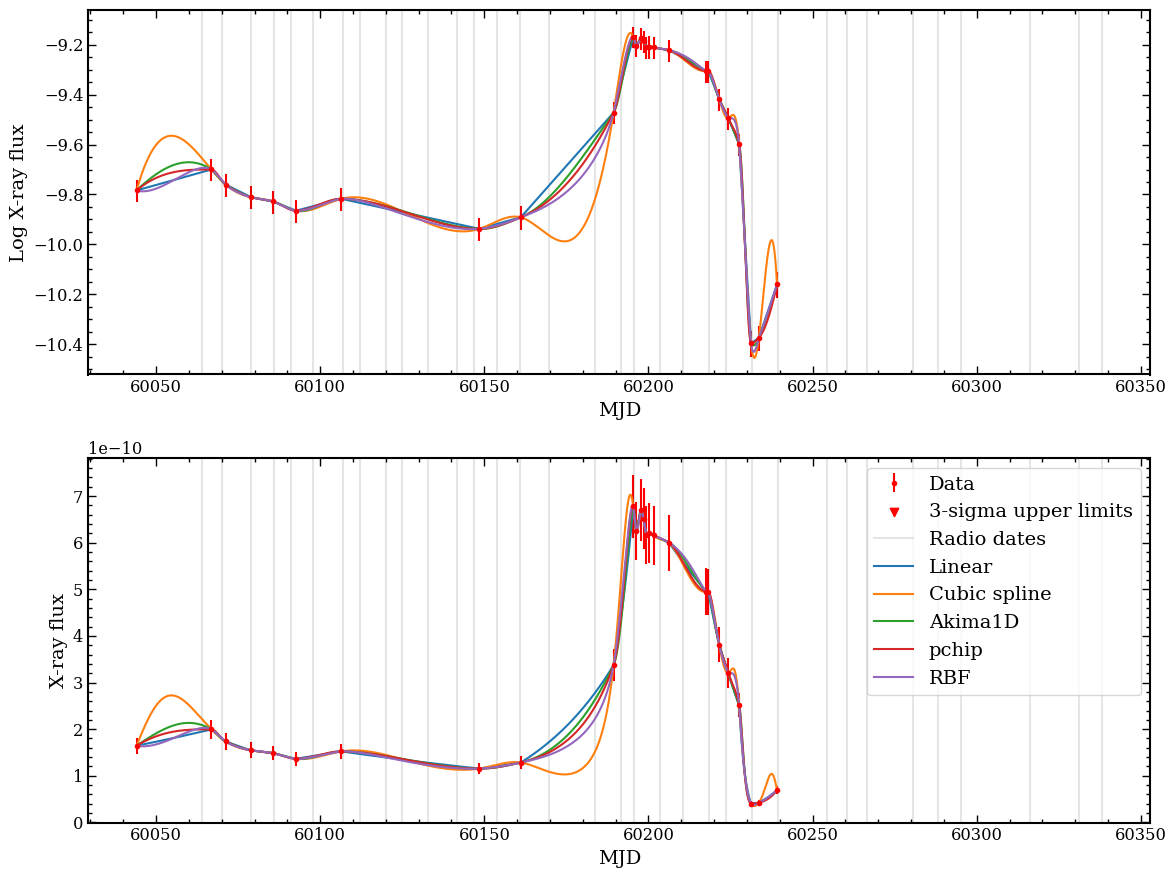

In [61]:
run_interpolation_test(names=["MAXI J1810-222"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

MAXI J1820+070
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


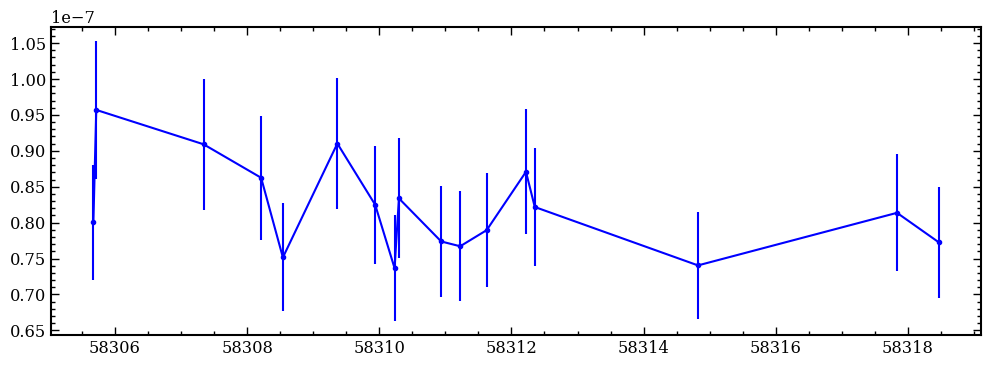

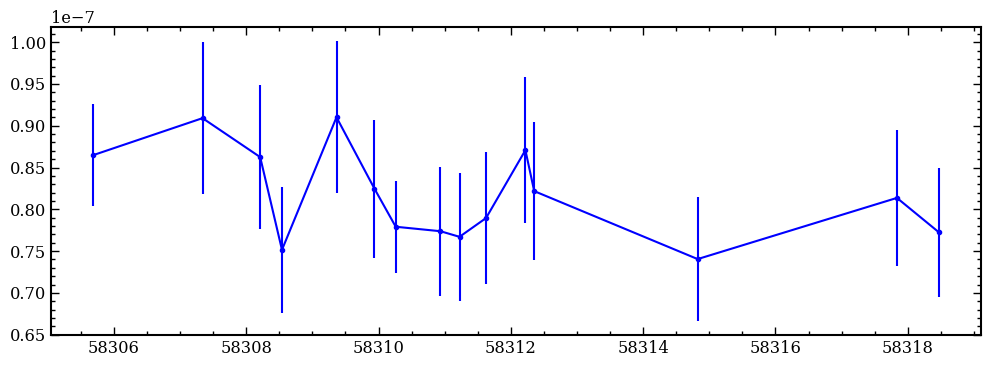

MAXI J1820+070
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


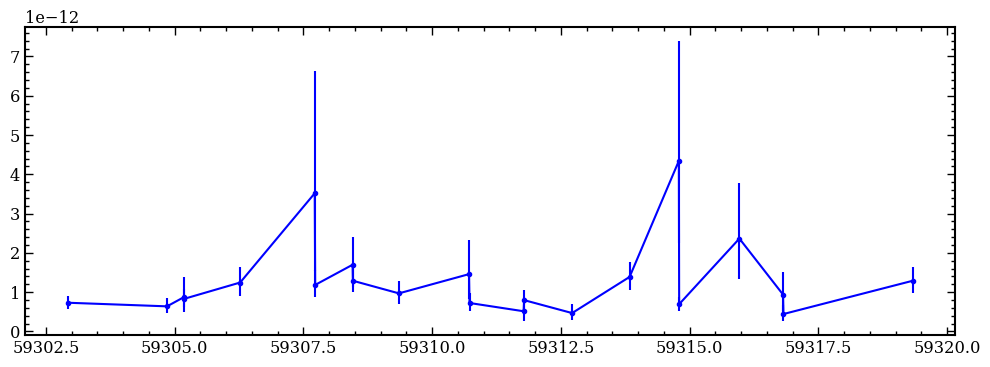

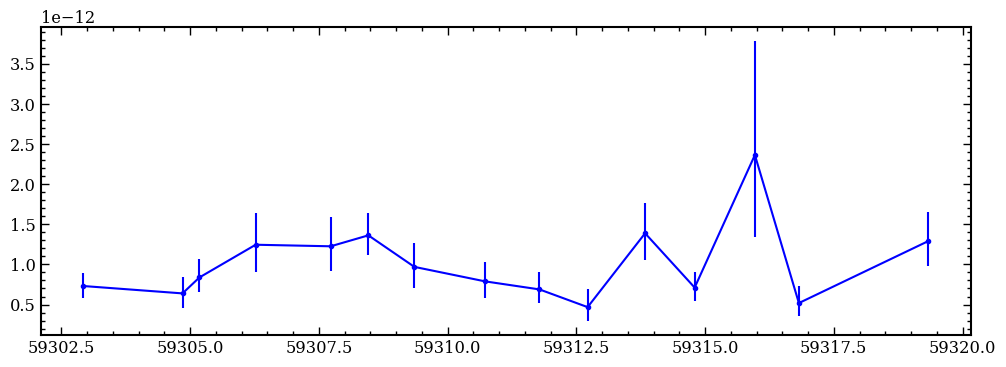

MAXI J1820+070
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


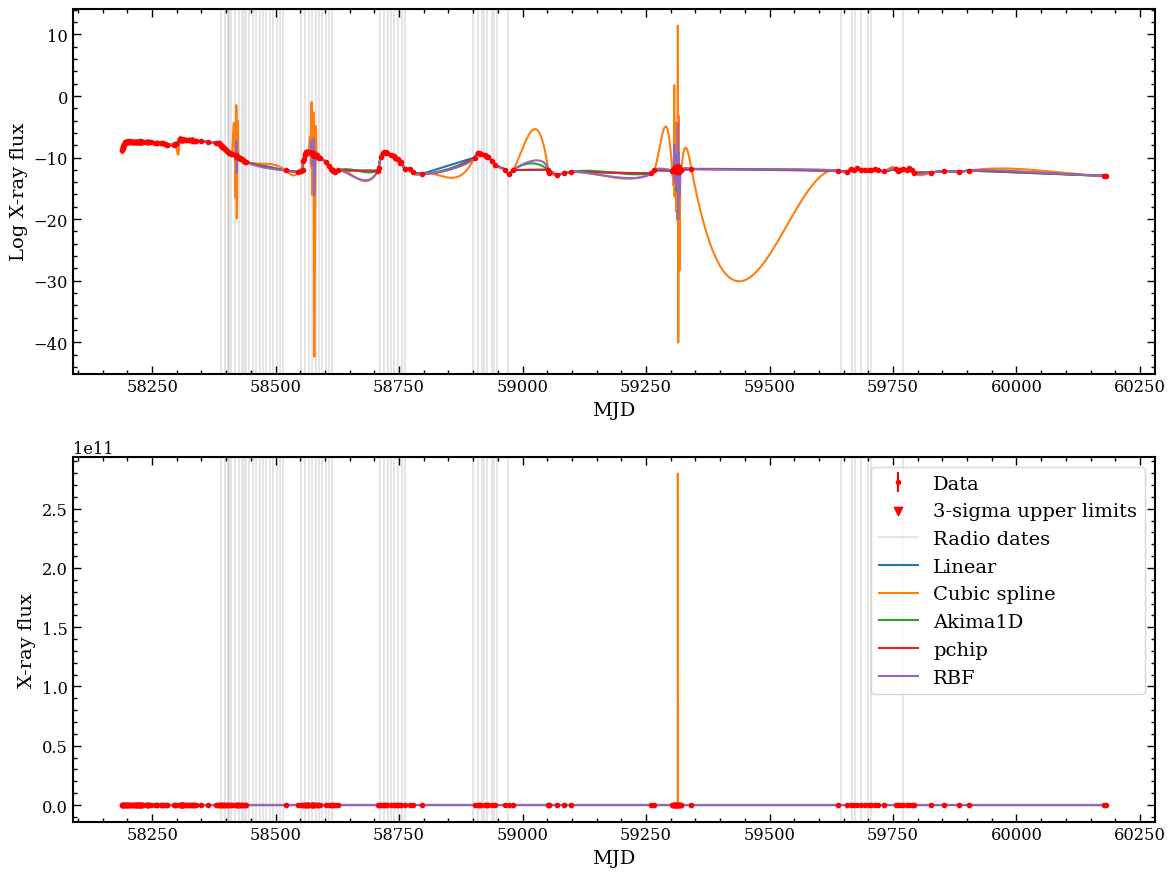

In [67]:
show_merging_effect("MAXI J1820+070", mjd1 = 58300, mjd2 = 58320)
show_merging_effect("MAXI J1820+070", mjd1 = 59300, mjd2 = 59320)
run_interpolation_test(names=["MAXI J1820+070"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

SAX J1808.4-3658
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


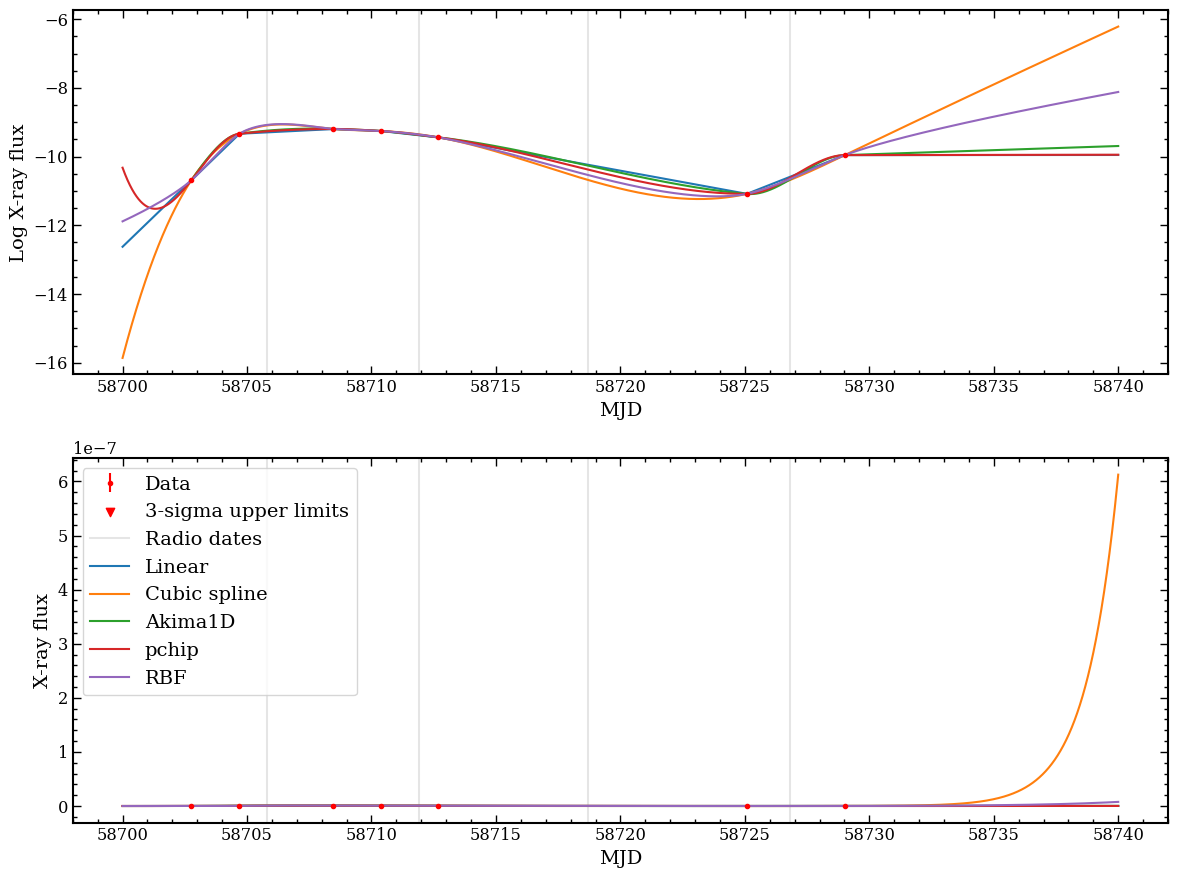

SAX J1808.4-3658
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


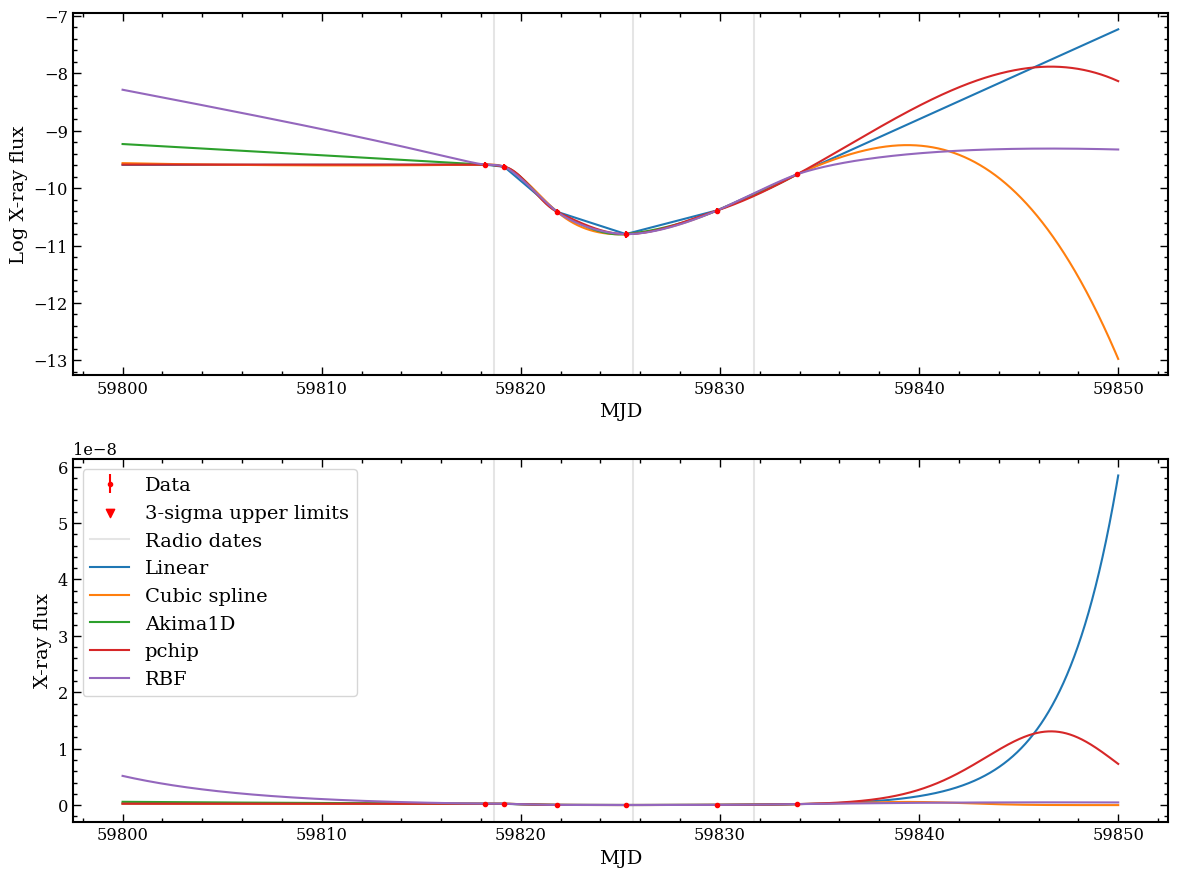

In [72]:
# Two disconnected parts, so break it up into two tests
run_interpolation_test(names=["SAX J1808.4-3658"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"], mjd1=58700, mjd2=58740)
run_interpolation_test(names=["SAX J1808.4-3658"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"], mjd1=59800, mjd2=59850)

SAX J1810.8-2609
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  90
Converting uncertainties to 68% (assuming Gaussian errors).
Added 10.0% systematic uncertainty to the X-ray data.


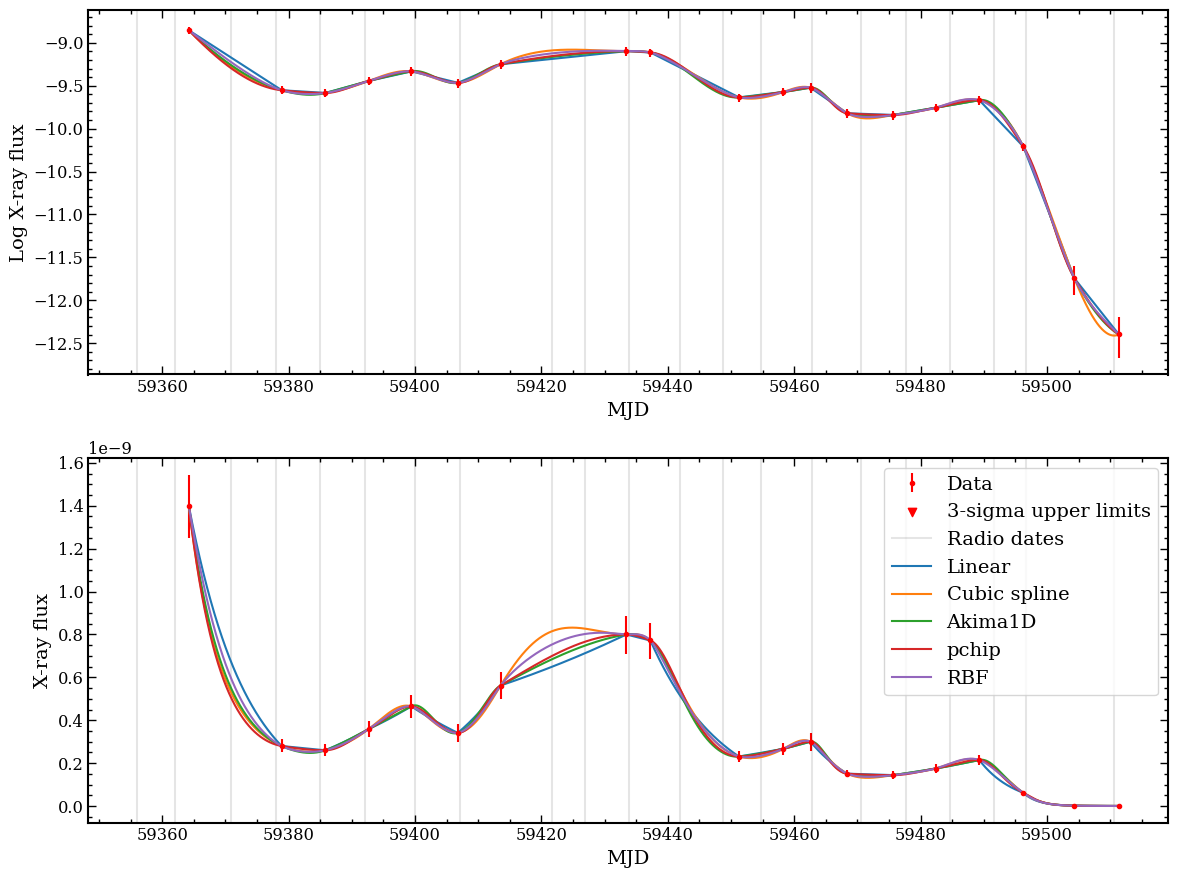

In [23]:
run_interpolation_test(names=["SAX J1810.8-2609"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

Swift J1727.8-1613
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


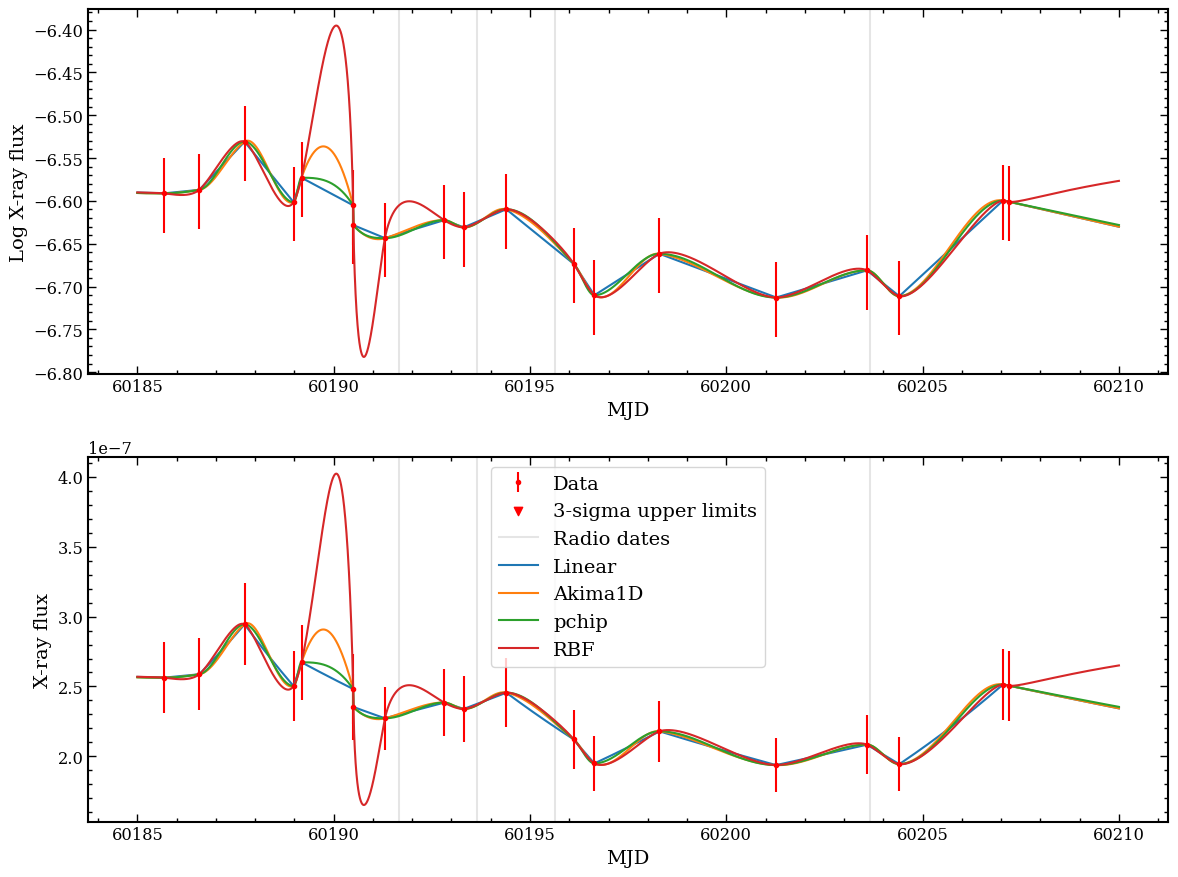

Swift J1727.8-1613
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


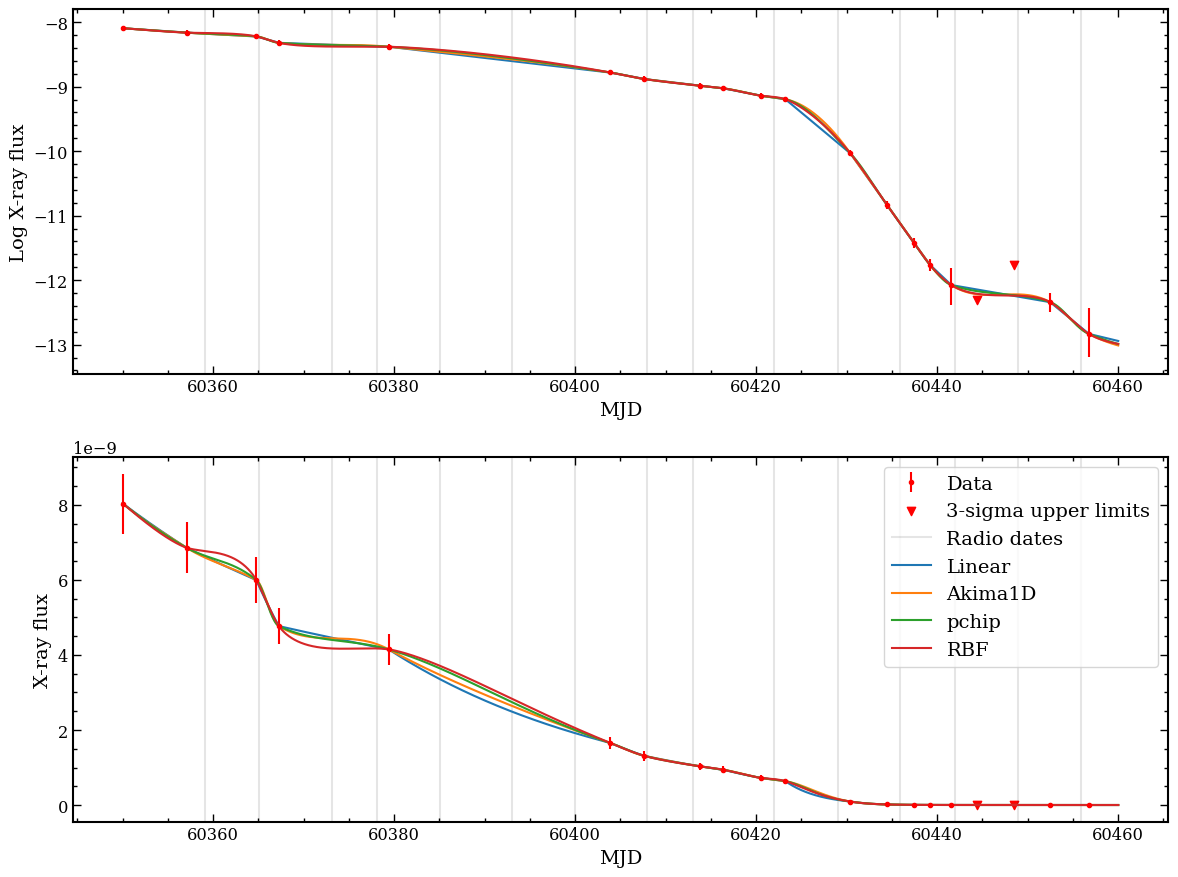

In [88]:
# Two disconnected parts, so break it up into two tests
run_interpolation_test(names=["Swift J1727.8-1613"], types=[ "pchip", "akima", "rbf", "linear"], mjd1 =  60185, mjd2=60210) # "cubic_spline",
run_interpolation_test(names=["Swift J1727.8-1613"], types=[ "pchip", "akima", "rbf", "linear"], mjd1 =  60350, mjd2=60460)

Swift J1842.5-1124
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


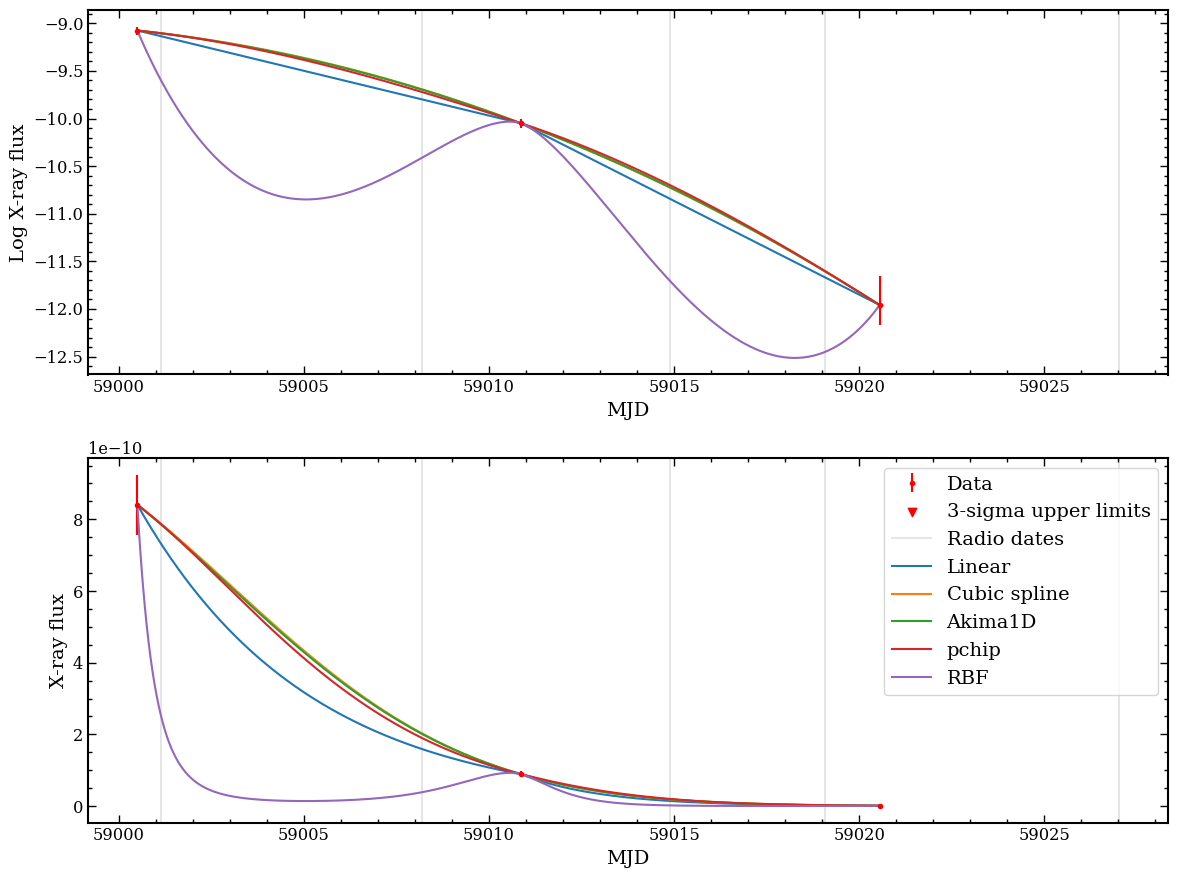

In [91]:
run_interpolation_test(names=["Swift J1842.5-1124"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"])

XTE J1701-462
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 20.0% systematic uncertainty to the X-ray data.


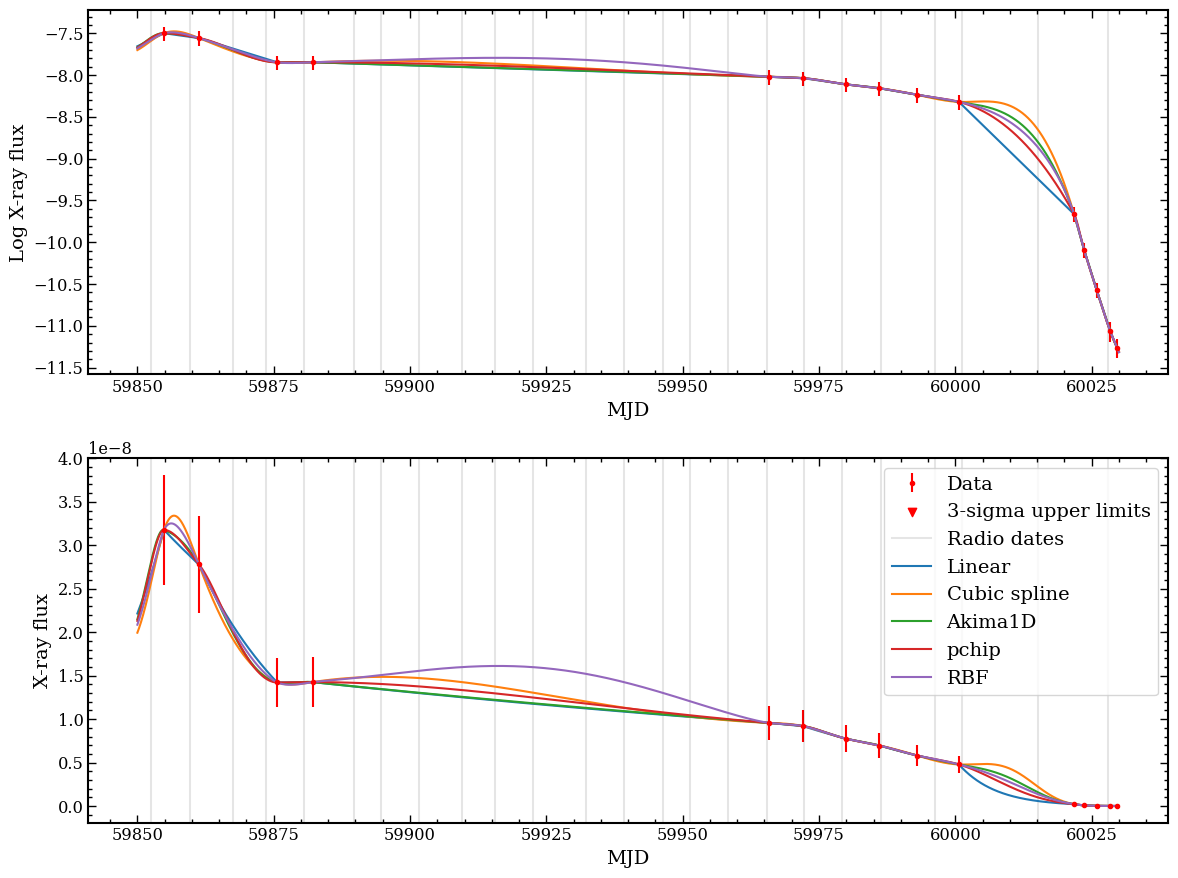

In [95]:
run_interpolation_test(names=["XTE J1701-462"], types=["cubic_spline", "pchip", "akima", "rbf", "linear"], mjd1=59850, mjd2=60030)